In [42]:
import pandas as pd

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [43]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [44]:
train.isnull().sum()

Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

In [45]:
train.describe(include="all")

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
count,77299.000000,77299,77299.000000,77299,7.729900e+04,76699,77299.000000,77299,77299,74804.000000,76502
unique,NaN,1249,NaN,96,NaN,3,NaN,2,2,NaN,4
top,NaN,qp03xk,NaN,2:0,NaN,Residential,NaN,Not Allowed,Yes,NaN,Sunny
freq,NaN,105,NaN,1778,NaN,69230,NaN,50673,52042,NaN,27717
mean,38649.000000,NaN,48.101838,NaN,9.394238e-02,NaN,2.014334,NaN,NaN,16.405354,NaN
std,22314.443566,NaN,0.302438,NaN,1.421905e-01,NaN,0.904665,NaN,NaN,7.359835,NaN
min,0.000000,NaN,48.000000,NaN,6.245650e-07,NaN,1.000000,NaN,NaN,-14.935097,NaN
25%,19324.500000,NaN,48.000000,NaN,1.822723e-02,NaN,1.000000,NaN,NaN,11.430473,NaN
50%,38649.000000,NaN,48.000000,NaN,4.775994e-02,NaN,2.000000,NaN,NaN,16.382587,NaN
75%,57973.500000,NaN,48.000000,NaN,1.085951e-01,NaN,3.000000,NaN,NaN,21.298833,NaN


In [46]:
train["demand"].describe()

count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64

In [47]:
train.columns

Index(['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType',
       'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature',
       'Weather'],
      dtype='object')

In [48]:
train["timestamp"].unique()[:20]

array(['0:0', '0:15', '0:30', '0:45', '1:0', '1:15', '1:30', '1:45',
       '2:0', '2:15', '2:30', '2:45', '3:0', '3:15', '3:30', '3:45',
       '4:0', '4:15', '4:30', '4:45'], dtype=object)

In [49]:
train["RoadType"].value_counts(dropna=False)

RoadType
Residential    69230
Street          3909
Highway         3560
NaN              600
Name: count, dtype: int64

In [50]:
train["Weather"].value_counts(dropna=False)

Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
NaN        797
Name: count, dtype: int64

In [51]:
train["LargeVehicles"].value_counts()

LargeVehicles
Not Allowed    50673
Allowed        26626
Name: count, dtype: int64

In [52]:
train["Landmarks"].value_counts()

Landmarks
Yes    52042
No     25257
Name: count, dtype: int64

In [53]:
train["geohash"].nunique()

1249

In [54]:
train.groupby("RoadType")["demand"].mean()

RoadType
Highway        0.610756
Residential    0.057209
Street         0.273164
Name: demand, dtype: float64

In [55]:
train.groupby("Weather")["demand"].mean()

Weather
Foggy    0.093372
Rainy    0.094471
Snowy    0.092581
Sunny    0.094247
Name: demand, dtype: float64

In [56]:
train.groupby("NumberofLanes")["demand"].mean()

NumberofLanes
1    0.088104
2    0.077488
3    0.077859
4    0.602882
5    0.607556
Name: demand, dtype: float64

In [57]:
train.groupby("LargeVehicles")["demand"].mean()

LargeVehicles
Allowed        0.131923
Not Allowed    0.073986
Name: demand, dtype: float64

In [58]:
train.groupby("Landmarks")["demand"].mean()

Landmarks
No     0.096295
Yes    0.092801
Name: demand, dtype: float64

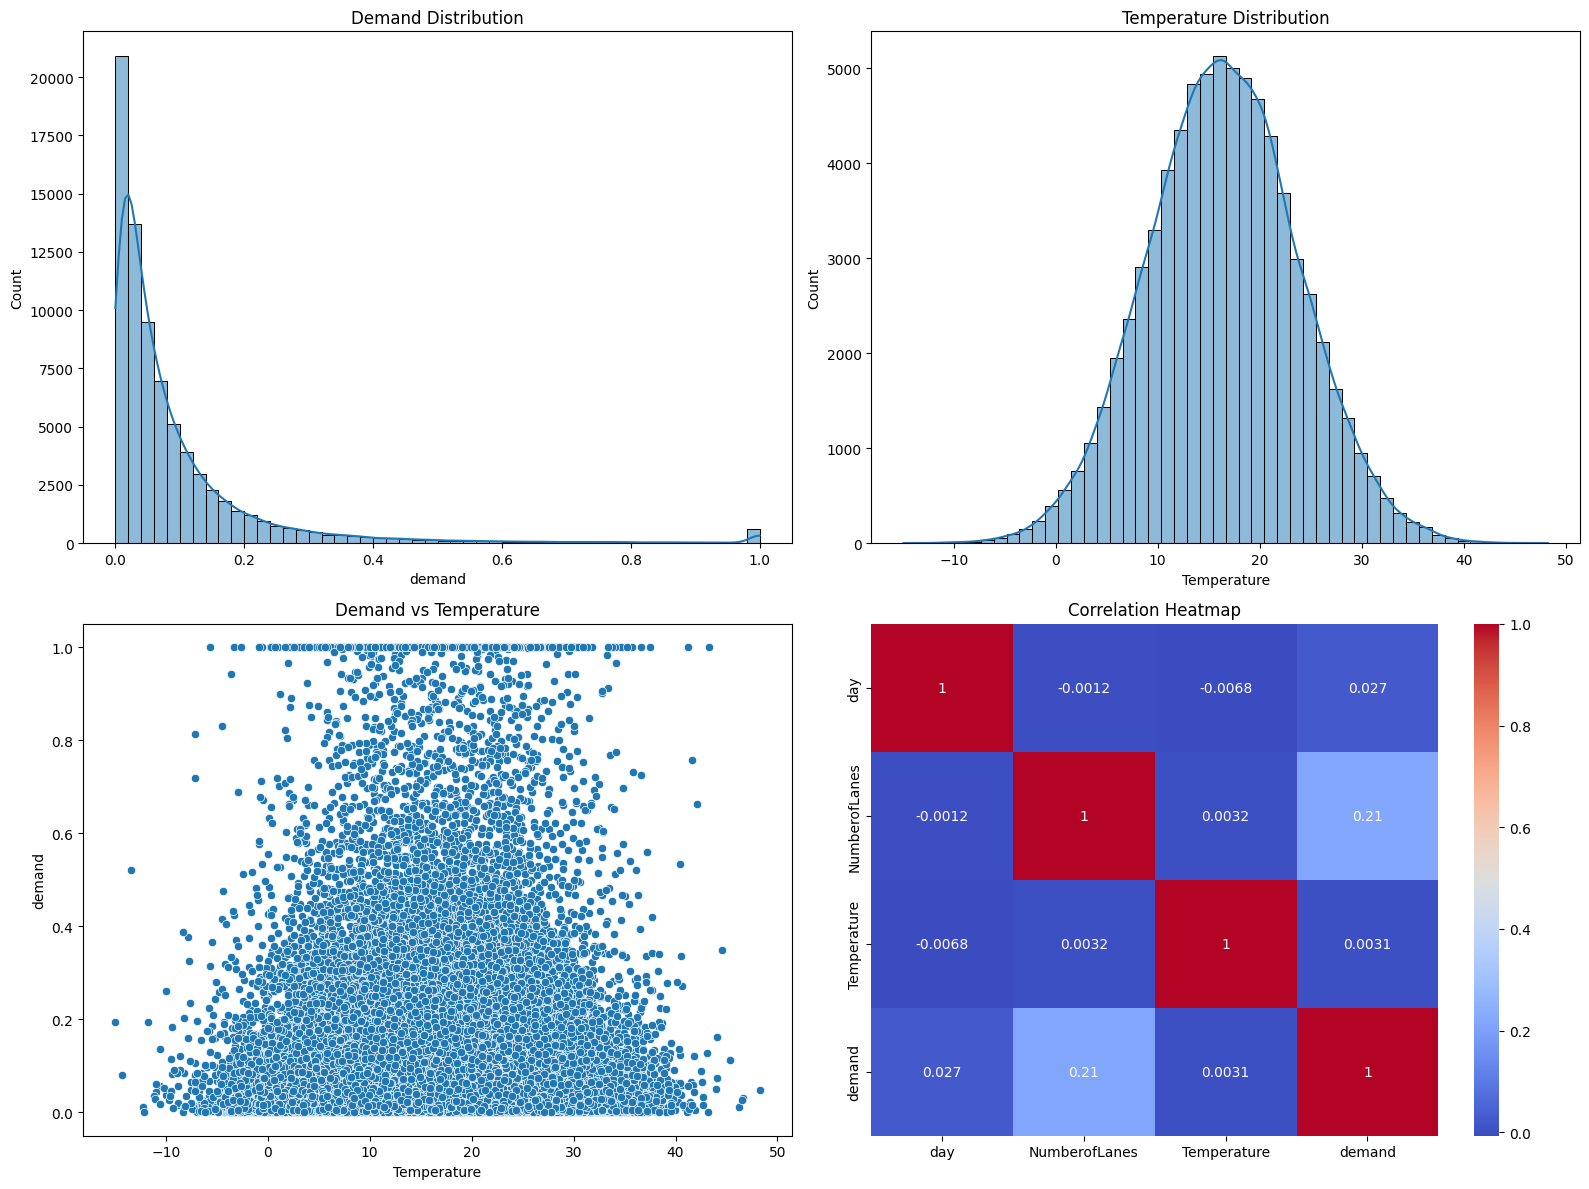

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Demand Distribution
sns.histplot(train["demand"], bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title("Demand Distribution")

# Temperature Distribution
sns.histplot(train["Temperature"], bins=50, kde=True, ax=axes[0,1])
axes[0,1].set_title("Temperature Distribution")

# Demand vs Temperature
sns.scatterplot(
    x=train["Temperature"],
    y=train["demand"],
    ax=axes[1,0]
)
axes[1,0].set_title("Demand vs Temperature")

# Correlation Heatmap
numeric_cols = [
    "day",
    "NumberofLanes",
    "Temperature",
    "demand"
]

sns.heatmap(
    train[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    ax=axes[1,1]
)
axes[1,1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

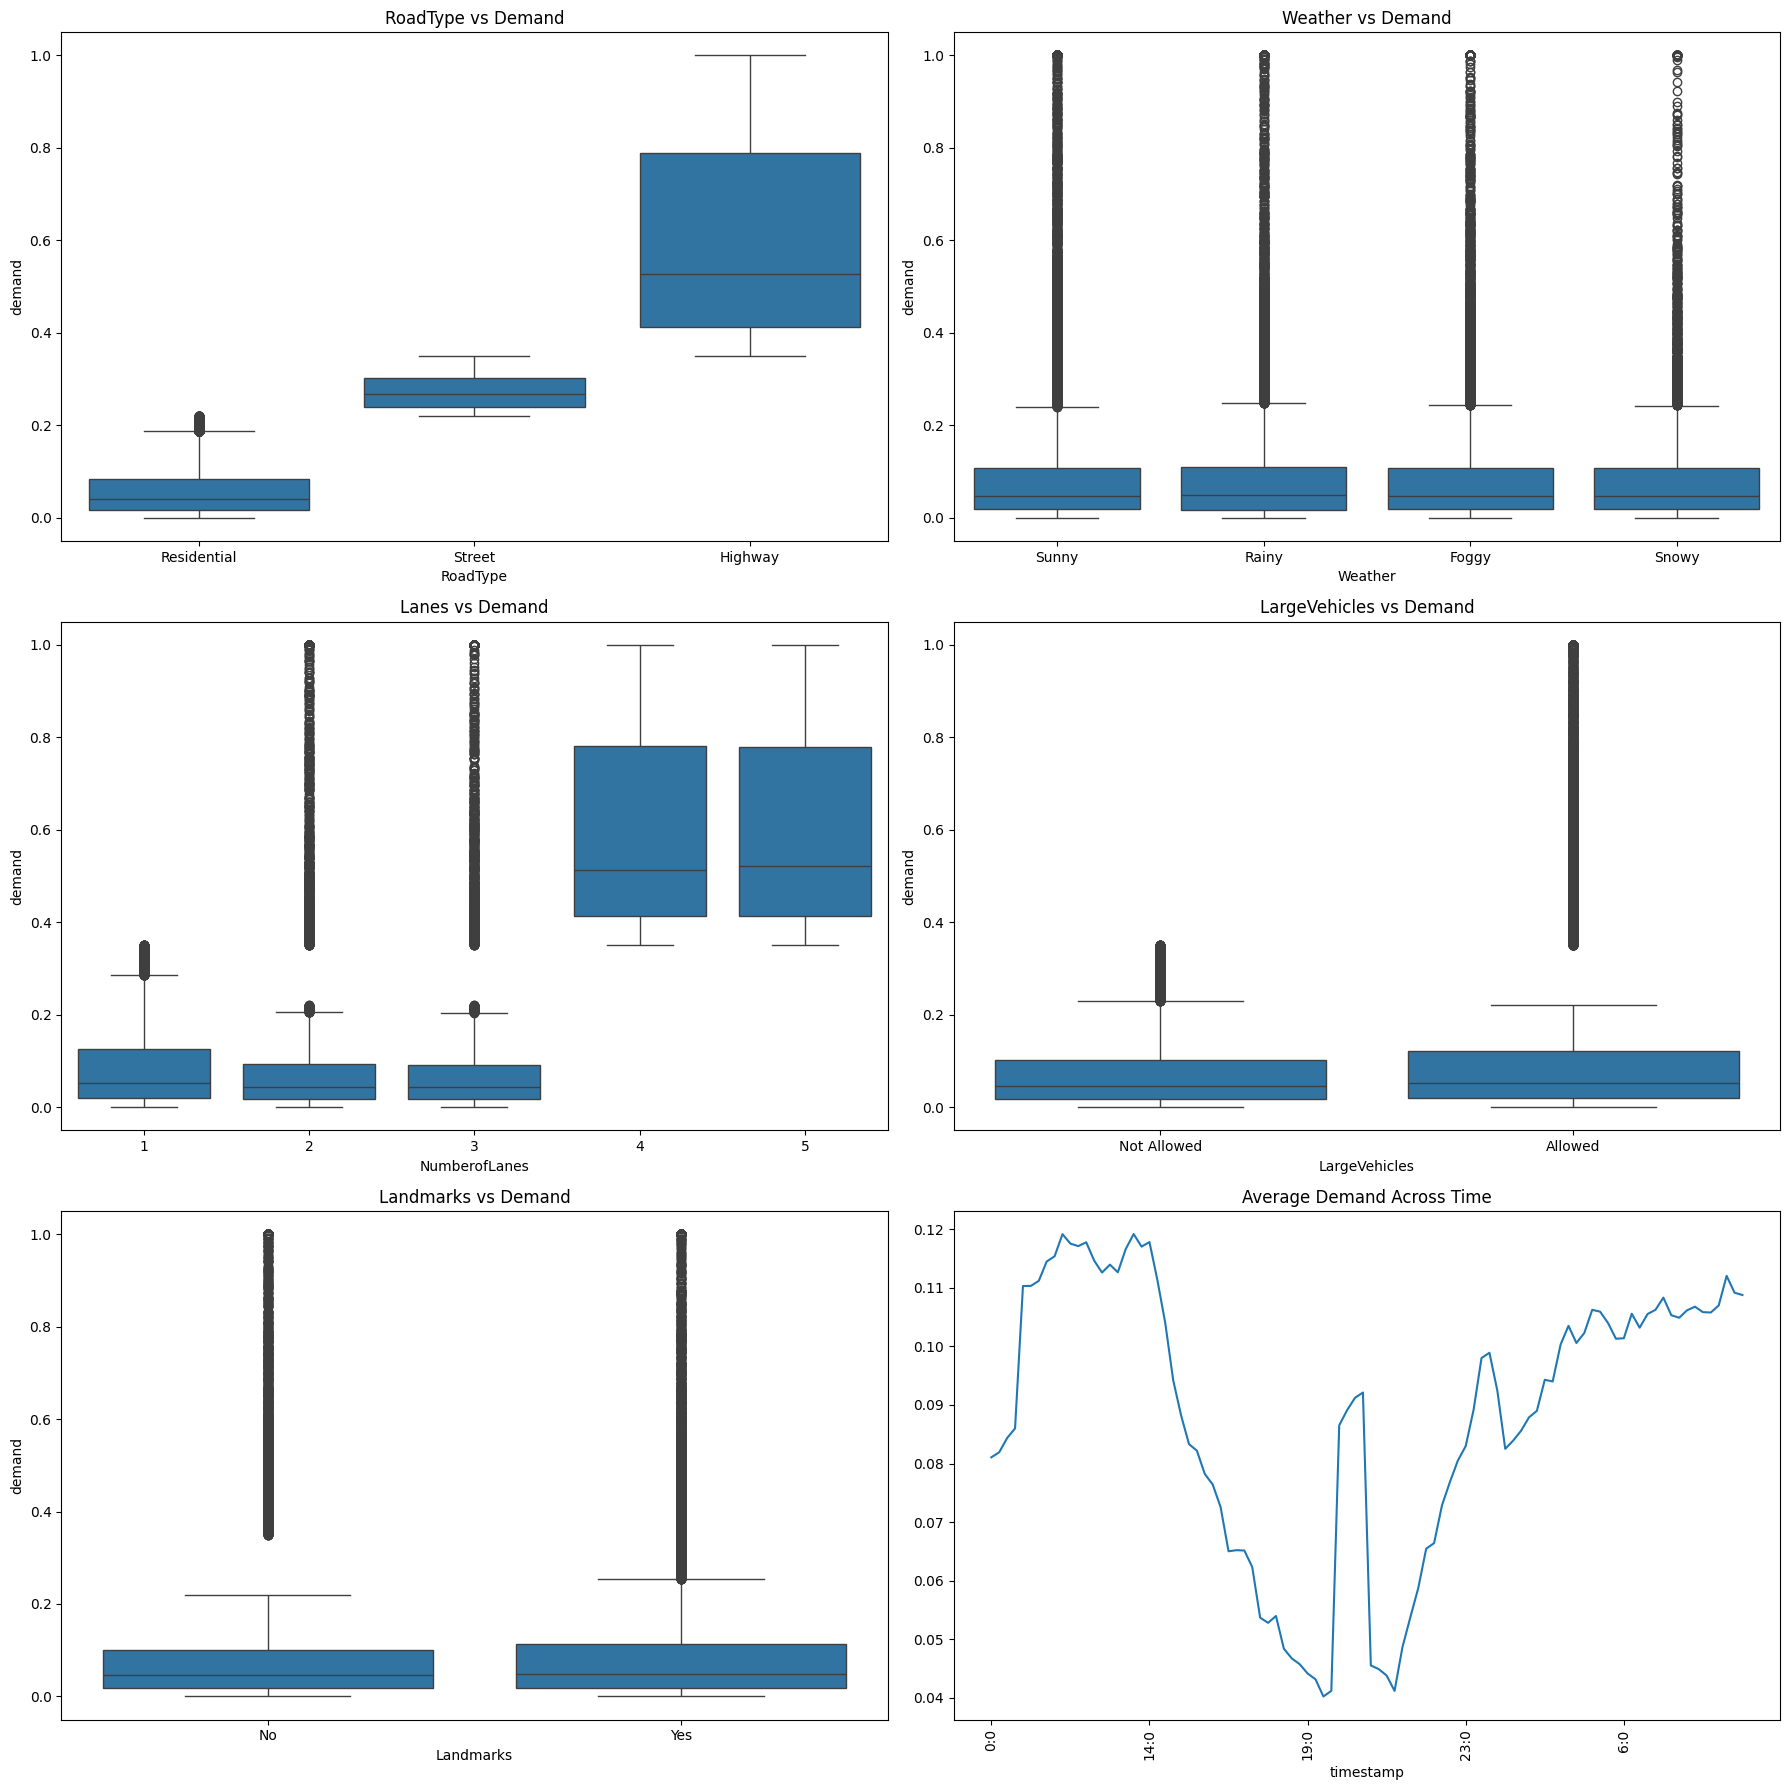

In [60]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# RoadType vs Demand
sns.boxplot(
    x="RoadType",
    y="demand",
    data=train,
    ax=axes[0,0]
)
axes[0,0].set_title("RoadType vs Demand")

# Weather vs Demand
sns.boxplot(
    x="Weather",
    y="demand",
    data=train,
    ax=axes[0,1]
)
axes[0,1].set_title("Weather vs Demand")

# Lanes vs Demand
sns.boxplot(
    x="NumberofLanes",
    y="demand",
    data=train,
    ax=axes[1,0]
)
axes[1,0].set_title("Lanes vs Demand")

# LargeVehicles vs Demand
sns.boxplot(
    x="LargeVehicles",
    y="demand",
    data=train,
    ax=axes[1,1]
)
axes[1,1].set_title("LargeVehicles vs Demand")

# Landmarks vs Demand
sns.boxplot(
    x="Landmarks",
    y="demand",
    data=train,
    ax=axes[2,0]
)
axes[2,0].set_title("Landmarks vs Demand")

# Time Pattern
avg_time_demand = train.groupby("timestamp")["demand"].mean()

avg_time_demand.plot(
    ax=axes[2,1]
)

axes[2,1].set_title("Average Demand Across Time")
axes[2,1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [61]:
train.groupby("day")["timestamp"].nunique()

day
48    96
49     9
Name: timestamp, dtype: int64

In [62]:
test.groupby("day")["timestamp"].nunique()

day
49    47
Name: timestamp, dtype: int64

In [64]:
sorted(train[train["day"] == 49]["timestamp"].unique())

['0:0', '0:15', '0:30', '0:45', '1:0', '1:15', '1:30', '1:45', '2:0']

In [63]:
sorted(test[test["day"] == 49]["timestamp"].unique())[:20]

['10:0',
 '10:15',
 '10:30',
 '10:45',
 '11:0',
 '11:15',
 '11:30',
 '11:45',
 '12:0',
 '12:15',
 '12:30',
 '12:45',
 '13:0',
 '13:15',
 '13:30',
 '13:45',
 '2:15',
 '2:30',
 '2:45',
 '3:0']

In [65]:
early_times = [
    '0:0', '0:15', '0:30', '0:45',
    '1:0', '1:15', '1:30', '1:45', '2:0'
]

day48_early = train[
    (train["day"] == 48) &
    (train["timestamp"].isin(early_times))
]

day49_early = train[
    (train["day"] == 49)
]

geo48 = day48_early.groupby("geohash")["demand"].mean()
geo49 = day49_early.groupby("geohash")["demand"].mean()

ratio = (geo49 / geo48)

print(ratio.describe())

count    996.000000
mean       2.160886
std        5.686674
min        0.000399
25%        1.025551
50%        1.541338
75%        2.317931
max      155.771508
Name: demand, dtype: float64


In [66]:
print(ratio.sort_values().head(10))
print(ratio.sort_values().tail(10))

geohash
qp09v3    0.000399
qp0948    0.036825
qp0903    0.055918
qp0d1w    0.105174
qp02zm    0.124979
qp09ec    0.133334
qp0d0c    0.137446
qp06nt    0.156554
qp091s    0.157130
qp09ce    0.217216
Name: demand, dtype: float64
geohash
qp0dhc   NaN
qp0dhu   NaN
qp0dj8   NaN
qp0dj9   NaN
qp0djd   NaN
qp0dje   NaN
qp0djf   NaN
qp0dju   NaN
qp0dn0   NaN
qp0dn4   NaN
Name: demand, dtype: float64


In [67]:
early_times = [
    '0:0', '0:15', '0:30', '0:45',
    '1:0', '1:15', '1:30', '1:45', '2:0'
]

day48 = train[train["day"] == 48].copy()
day49_early = train[train["day"] == 49].copy()

d48_early = day48[day48["timestamp"].isin(early_times)]

global_ratio = day49_early["demand"].mean() / d48_early["demand"].mean()

print("global_ratio:", global_ratio)

for col in ["RoadType", "NumberofLanes", "LargeVehicles", "Weather", "Landmarks"]:
    r48 = d48_early.groupby(col)["demand"].mean()
    r49 = day49_early.groupby(col)["demand"].mean()
    ratio = (r49 / r48).replace([float("inf"), -float("inf")], None)
    print("\n", col)
    print(ratio)

global_ratio: 1.5567853342197229

 RoadType
RoadType
Highway        1.084708
Residential    1.220424
Street         0.986269
Name: demand, dtype: float64

 NumberofLanes
NumberofLanes
1    1.423601
2    1.479853
3    1.376020
4    1.189319
5    1.074438
Name: demand, dtype: float64

 LargeVehicles
LargeVehicles
Allowed        1.855445
Not Allowed    1.356731
Name: demand, dtype: float64

 Weather
Weather
Foggy    1.522486
Rainy    1.528734
Snowy    1.395968
Sunny    1.653710
Name: demand, dtype: float64

 Landmarks
Landmarks
No     1.751659
Yes    1.472049
Name: demand, dtype: float64
